# 🌍 World Happiness Report 2015
### *Unique Visualizations from DataVizProject.com*

**Author:** Om Dipak Patil  
**Dataset:** World Happiness Report 2015 (158 countries)  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Plotly, Squarify, PyWaffle  
**Visualization Reference:** [datavizproject.com](https://datavizproject.com/)

---

### Story Arc
1. **Who is happiest?** — Rankings and distributions
2. **Where is happiness concentrated?** — Regional patterns
3. **What drives happiness?** — Factor contributions
4. **How do factors interrelate?** — Multi-variable analysis
5. **Who are the outliers?** — Anomaly detection

---

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import squarify
from pywaffle import Waffle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Colorblind-safe palette (Wong 2011)
CB_PALETTE = [
    '#0072B2', '#E69F00', '#009E73', '#CC79A7',
    '#56B4E9', '#D55E00', '#F0E442', '#000000',
    '#332288', '#88CCEE', '#44AA99'
]

print("Libraries imported ")

Libraries imported 


---
## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('2015.csv')

# Ensure numeric columns
num_cols = ['Happiness Score','Economy (GDP per Capita)','Family',
            'Health (Life Expectancy)','Freedom',
            'Trust (Government Corruption)','Generosity','Dystopia Residual']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=['Happiness Score'], inplace=True)

# Happiness tier labels
df['Happiness Tier'] = pd.cut(
    df['Happiness Score'],
    bins=[0, 4, 5, 6, 8],
    labels=['Low (<4)', 'Medium (4–5)', 'High (5–6)', 'Very High (>6)']
)

# Region color mapping (colorblind-safe)
regions = df['Region'].unique()
region_color = dict(zip(regions, CB_PALETTE[:len(regions)]))

factors = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
           'Freedom', 'Trust (Government Corruption)', 'Generosity']

print(f"Countries: {len(df)} | Regions: {df['Region'].nunique()}")
print(f"Score range: {df['Happiness Score'].min():.2f} – {df['Happiness Score'].max():.2f}")
print("\nSummary:")
print(df[['Happiness Score'] + factors].describe().round(3))

Countries: 158 | Regions: 10
Score range: 2.84 – 7.59

Summary:
       Happiness Score  Economy (GDP per Capita)   Family  \
count          158.000                   158.000  158.000   
mean             5.376                     0.846    0.991   
std              1.145                     0.403    0.272   
min              2.839                     0.000    0.000   
25%              4.526                     0.546    0.857   
50%              5.232                     0.910    1.030   
75%              6.244                     1.158    1.214   
max              7.587                     1.690    1.402   

       Health (Life Expectancy)  Freedom  Trust (Government Corruption)  \
count                   158.000  158.000                        158.000   
mean                      0.630    0.429                          0.143   
std                       0.247    0.151                          0.120   
min                       0.000    0.000                          0.000   
25%        

---
# 🏆 ACT 1 — Who Is Happiest?

## Visualization 1 — Top & Bottom Countries by Happiness
### Type: Lollipop Chart *(datavizproject.com)*

**Why this chart?**  
A lollipop chart is a decluttered bar chart — the thin stem reduces ink while the dot focuses attention on the precise value. Showing the top 15 and bottom 15 countries side by side in contrasting colors (blue vs red) uses preattentive color to immediately separate winners from strugglers.

**Design improvements:** Colorblind-safe blue/red, sorted order, region-labeled annotations, minimal gridlines.

**Key insight:** Western Europe dominates the top 15. Sub-Saharan Africa occupies almost all bottom 15 positions.

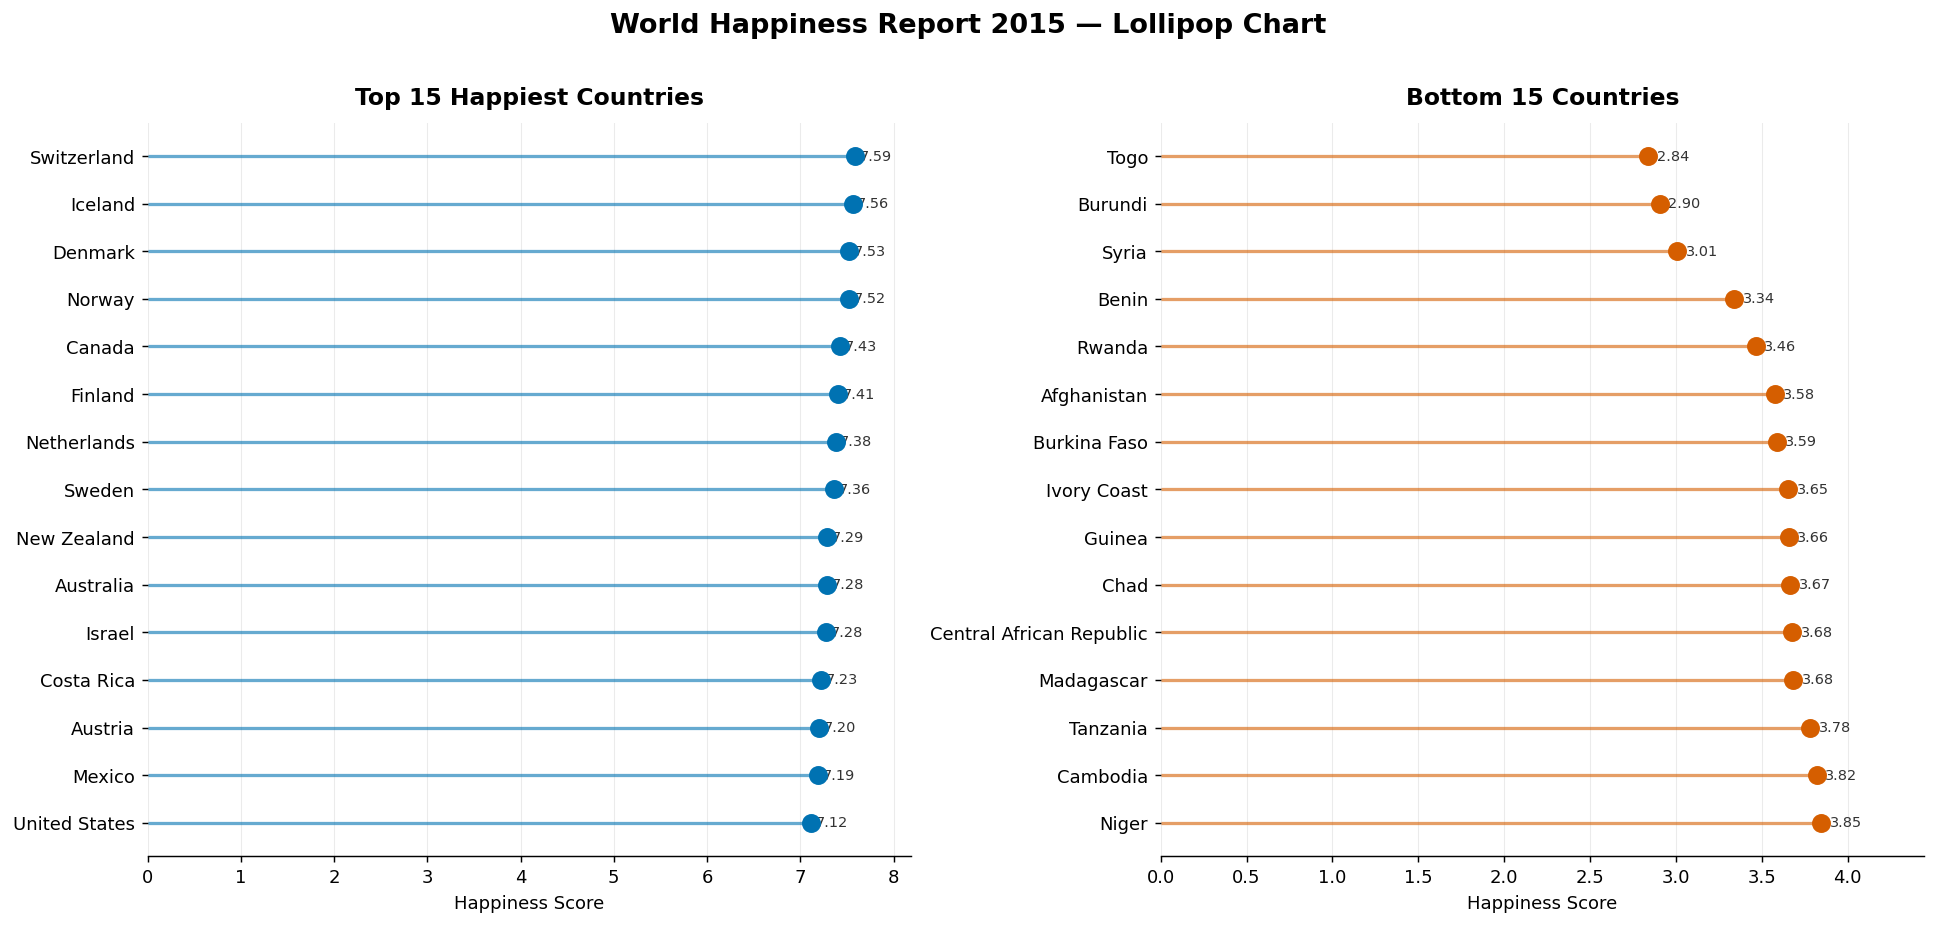

In [3]:
top15    = df.nlargest(15, 'Happiness Score').sort_values('Happiness Score')
bottom15 = df.nsmallest(15, 'Happiness Score').sort_values('Happiness Score', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, data, color, title in [
    (axes[0], top15,    '#0072B2', 'Top 15 Happiest Countries'),
    (axes[1], bottom15, '#D55E00', 'Bottom 15 Countries')
]:
    ax.hlines(y=data['Country'], xmin=0,
              xmax=data['Happiness Score'],
              color=color, linewidth=1.8, alpha=0.6)
    ax.scatter(data['Happiness Score'], data['Country'],
               color=color, s=90, zorder=5)

    for _, row in data.iterrows():
        ax.text(row['Happiness Score'] + 0.05, row['Country'],
                f"{row['Happiness Score']:.2f}",
                va='center', fontsize=8, color='#333333')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Happiness Score', fontsize=10)
    ax.set_xlim(0, data['Happiness Score'].max() + 0.6)
    ax.grid(True, axis='x', alpha=0.25, linewidth=0.6)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('World Happiness Report 2015 — Lollipop Chart',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz1_lollipop.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 2 — Score Distribution by Region
### Type: Violin Plot *(datavizproject.com)*

**Why this chart?**  
A violin plot combines a box plot with a kernel density estimate — it shows not just median and range, but the **full shape of the distribution**. This reveals whether a region has a tight or wide spread of happiness, and whether distributions are skewed or bimodal.

**Design improvements:** Regions sorted by median score, colorblind-safe palette, inner quartile box added, horizontal layout for label readability.

**Key insight:** Western Europe has a tight, high distribution. Sub-Saharan Africa has a wide spread — suggesting high inequality within the region.

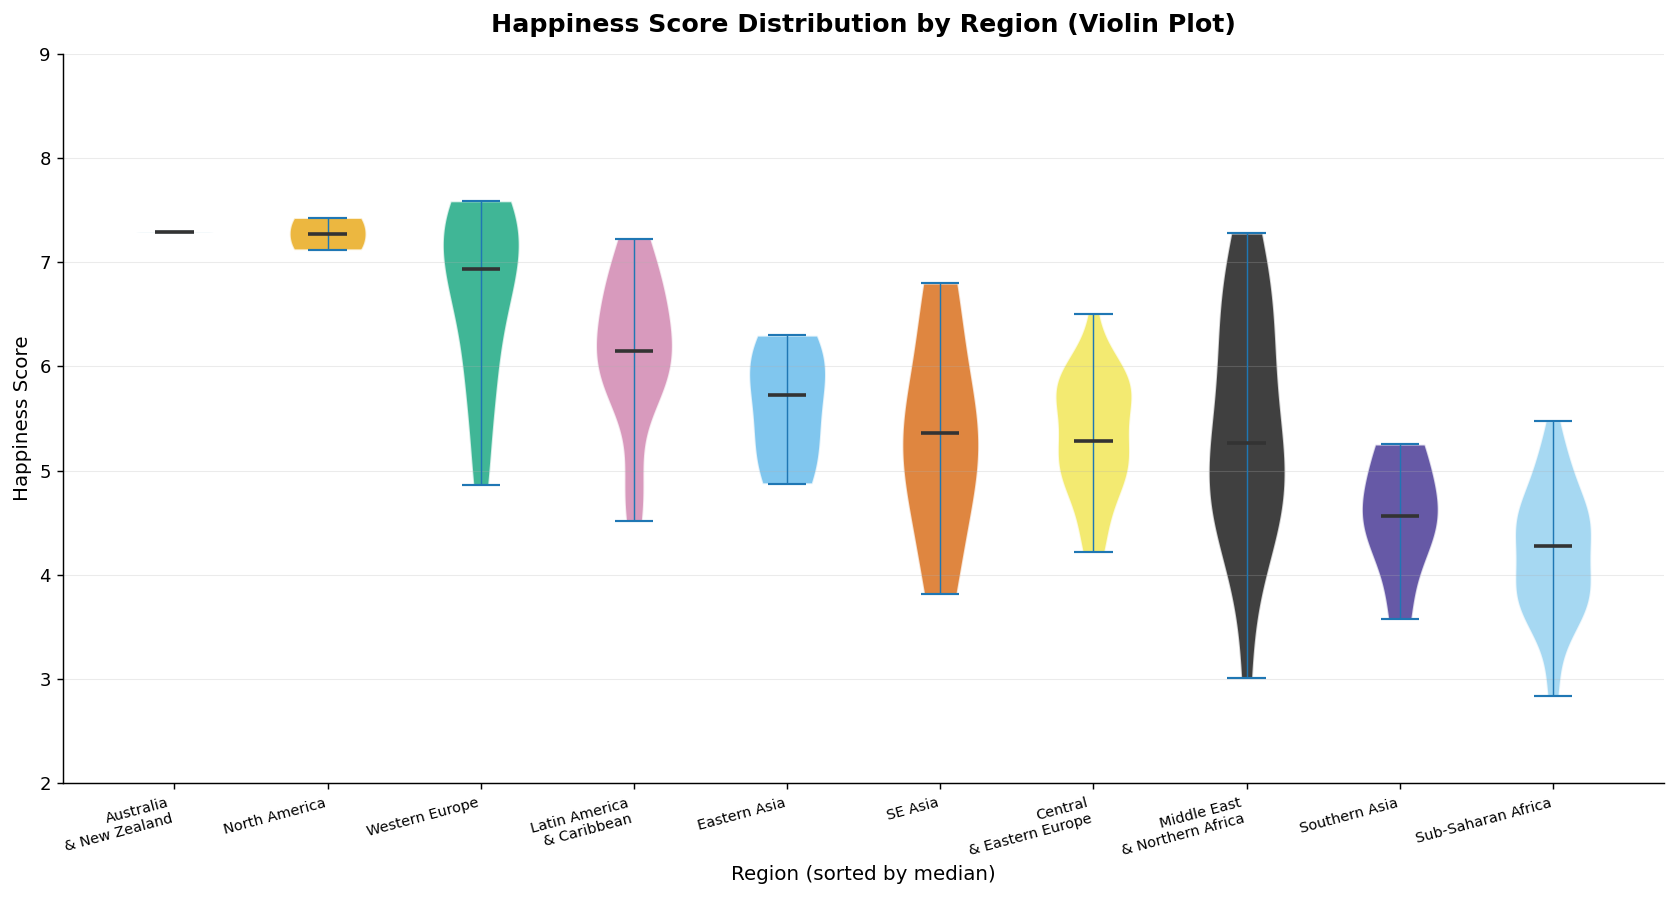

In [4]:
region_order = df.groupby('Region')['Happiness Score'].median()\
                 .sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(13, 7))

parts = ax.violinplot(
    [df[df['Region']==r]['Happiness Score'].values for r in region_order],
    positions=range(len(region_order)),
    vert=True, showmedians=True, showextrema=True
)

for i, (pc, region) in enumerate(zip(parts['bodies'], region_order)):
    pc.set_facecolor(CB_PALETTE[i % len(CB_PALETTE)])
    pc.set_alpha(0.75)
    pc.set_edgecolor('white')

parts['cmedians'].set_color('#333333')
parts['cmedians'].set_linewidth(2)
parts['cbars'].set_linewidth(0.8)
parts['cmaxes'].set_linewidth(1.2)
parts['cmins'].set_linewidth(1.2)

ax.set_xticks(range(len(region_order)))
ax.set_xticklabels([r.replace(' and ', '\n& ').replace('Southeastern', 'SE')
                     .replace('Central and Eastern', 'C&E')
                     .replace('Latin America and Caribbean', 'Latin America\n& Caribbean')
                     .replace('Middle East and Northern Africa', 'Middle East\n& N. Africa')
                     .replace('Australia and New Zealand', 'Aus &\nNew Zealand')
                     for r in region_order],
                   fontsize=8, rotation=15, ha='right')

ax.set_title('Happiness Score Distribution by Region (Violin Plot)',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Happiness Score', fontsize=11)
ax.set_xlabel('Region (sorted by median)', fontsize=11)
ax.grid(True, axis='y', alpha=0.25, linewidth=0.6)
ax.set_ylim(2, 9)

plt.tight_layout()
plt.savefig('viz2_violin.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 3 — Happiness Score Groups (Waffle Chart)
### Type: Waffle Chart *(datavizproject.com)*

**Why this chart?**  
A waffle chart is a unit-based alternative to a pie chart. Each square represents a country, making proportions intuitive and countable. This avoids the perceptual distortions of pie slices (humans are poor at estimating angles).

**Design improvements:** Colorblind-safe four-tier palette, clear legend with counts, grid layout makes proportions countable.

**Key insight:** Over half of the world's countries fall in the Medium (4–5) and High (5–6) bands. Only a small fraction achieve Very High scores (>6).

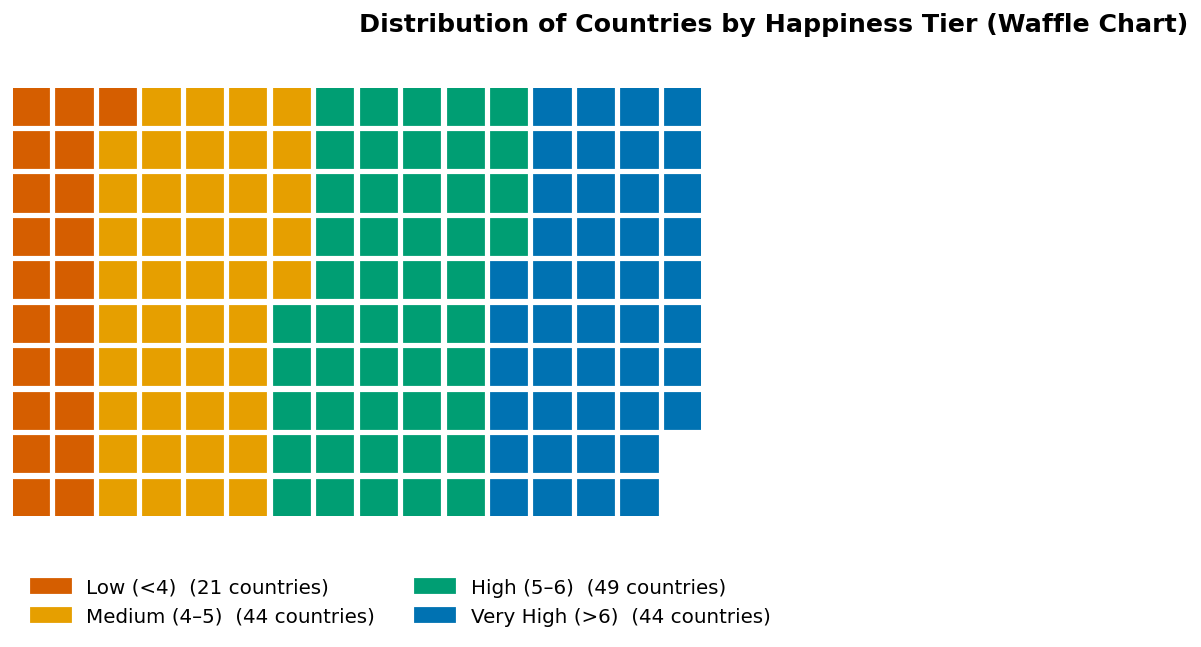

In [5]:
tier_counts = df['Happiness Tier'].value_counts().sort_index()
tier_colors = ['#D55E00', '#E69F00', '#009E73', '#0072B2']

fig = plt.figure(
    FigureClass=Waffle,
    rows=10,
    values=tier_counts.values.tolist(),
    labels=[f'{t}  ({v} countries)'
            for t, v in zip(tier_counts.index, tier_counts.values)],
    colors=tier_colors,
    figsize=(12, 5),
    legend={'loc': 'lower left', 'bbox_to_anchor': (0, -0.3),
            'ncol': 2, 'fontsize': 11, 'framealpha': 0},
    icon_style='solid',
    icon_size=18,
    starting_location='NW'
)

fig.suptitle('Distribution of Countries by Happiness Tier (Waffle Chart)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz3_waffle.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🌐 ACT 2 — Where Is Happiness Concentrated?

## Visualization 4 — Treemap: Countries by Region & Score
### Type: Treemap *(datavizproject.com)*

**Why this chart?**  
A treemap encodes **two variables simultaneously** — the size of each rectangle shows the Happiness Score, and color encodes the region. This allows the viewer to instantly see which regions dominate the "happiness space" and which individual countries are outliers within their region.

**Design improvements:** Regions grouped by color family, colorblind-safe palette, only top 50 countries labeled to reduce clutter.

**Key insight:** Western Europe rectangles dominate the top-right, while the many small rectangles from Sub-Saharan Africa occupy the bottom tier.

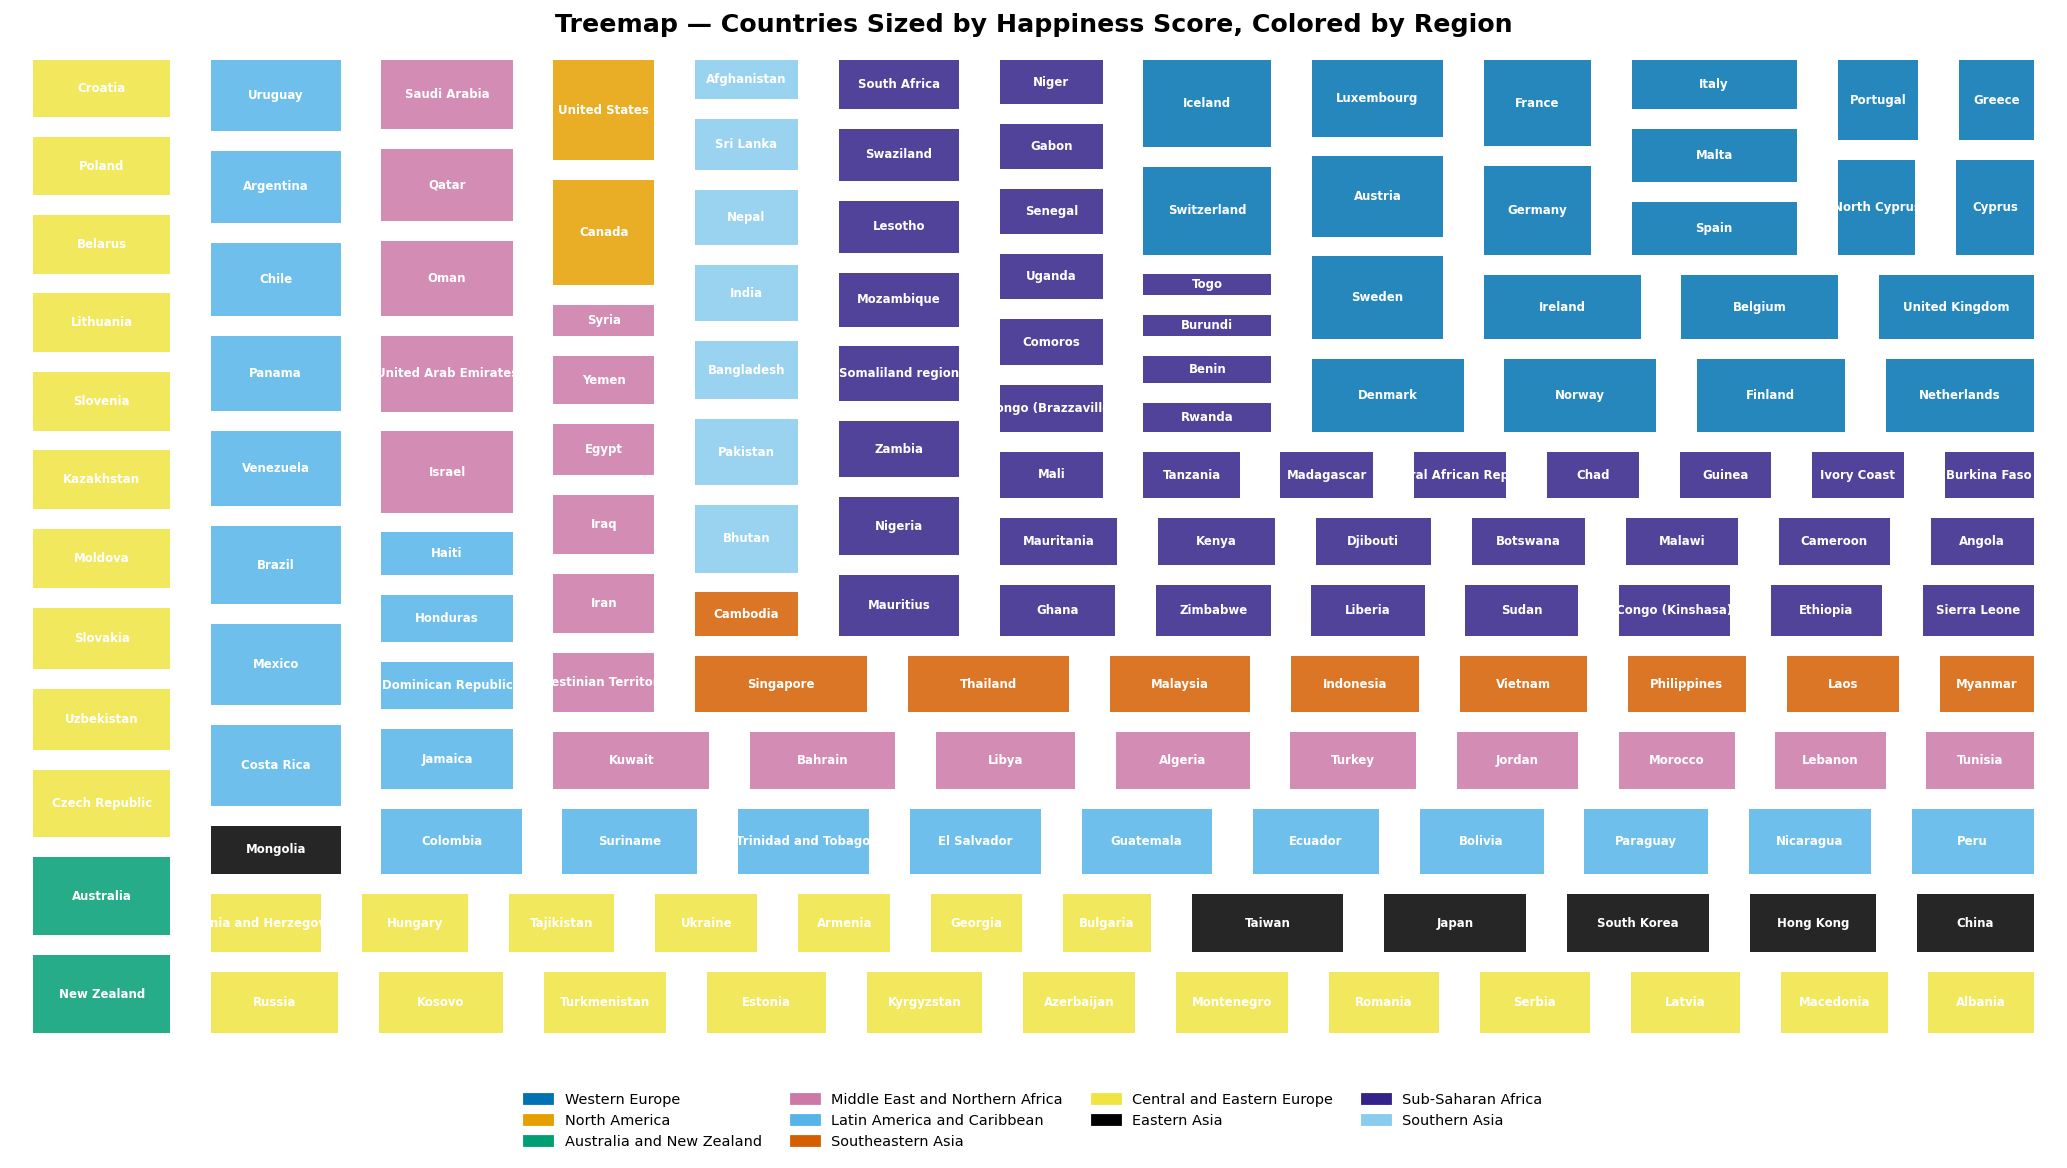

In [6]:
df_sorted = df.sort_values(['Region', 'Happiness Score'], ascending=[True, False])
colors_treemap = [CB_PALETTE[list(regions).index(r) % len(CB_PALETTE)]
                  for r in df_sorted['Region']]

fig, ax = plt.subplots(figsize=(16, 9))

squarify.plot(
    sizes=df_sorted['Happiness Score'],
    label=df_sorted['Country'],
    color=colors_treemap,
    alpha=0.85,
    text_kwargs={'fontsize': 6.5, 'color': 'white', 'fontweight': 'bold'},
    ax=ax,
    pad=True
)

ax.set_title('Treemap — Countries Sized by Happiness Score, Colored by Region',
             fontsize=14, fontweight='bold', pad=10)
ax.axis('off')

# Legend for regions
legend_handles = [
    mpatches.Patch(color=CB_PALETTE[i % len(CB_PALETTE)], label=r)
    for i, r in enumerate(regions)
]
ax.legend(handles=legend_handles, loc='lower center',
          bbox_to_anchor=(0.5, -0.12), ncol=4,
          fontsize=8, framealpha=0)

plt.tight_layout()
plt.savefig('viz4_treemap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 5 — Interactive Choropleth Map
### Type: Choropleth Map *(datavizproject.com)*

**Why this chart?**  
Geographic data is most naturally displayed on a map. Position (country location) is processed preattentively — viewers instantly see geographic clusters without reading labels. The sequential colorscale encodes happiness continuously.

**Design improvements:** RdYlGn colorscale (red = unhappy, green = happy), hover reveals all factors, diverging midpoint at global median.

**Key insight:** A clear north/south divide — prosperous northern nations score highest; conflict-affected regions in Africa/Middle East score lowest.

In [7]:
fig = px.choropleth(
    df,
    locations='Country',
    locationmode='country names',
    color='Happiness Score',
    hover_name='Country',
    hover_data={
        'Happiness Rank': True,
        'Happiness Score': ':.2f',
        'Region': True,
        'Economy (GDP per Capita)': ':.3f',
        'Family': ':.3f',
        'Freedom': ':.3f'
    },
    color_continuous_scale='RdYlGn',
    color_continuous_midpoint=df['Happiness Score'].median(),
    title='World Happiness Score 2015 — Choropleth Map'
)
fig.update_layout(
    title_font_size=15,
    geo=dict(showframe=False, showcoastlines=True, coastlinecolor='lightgray'),
    coloraxis_colorbar=dict(title='Happiness Score'),
    margin=dict(l=0, r=0, t=40, b=0),
    height=500
)
fig.show()

---
# 🔬 ACT 3 — What Drives Happiness?

## Visualization 6 — Radar / Spider Chart: Factor Profiles by Region
### Type: Radar Chart *(datavizproject.com)*

**Why this chart?**  
A radar chart is uniquely suited for comparing **multiple variables simultaneously** across categories. Each axis represents a happiness factor; the shape of the polygon reveals a region's "happiness profile" — whether it is strong across all factors or excels in only a few.

**Design improvements:** Normalized axes (0–1), colorblind-safe colors, filled polygons with transparency, top 5 regions shown to avoid visual overlap.

**Key insight:** Western Europe has a large, balanced polygon. Southern Asia scores very high on Family but very low on GDP and Trust.

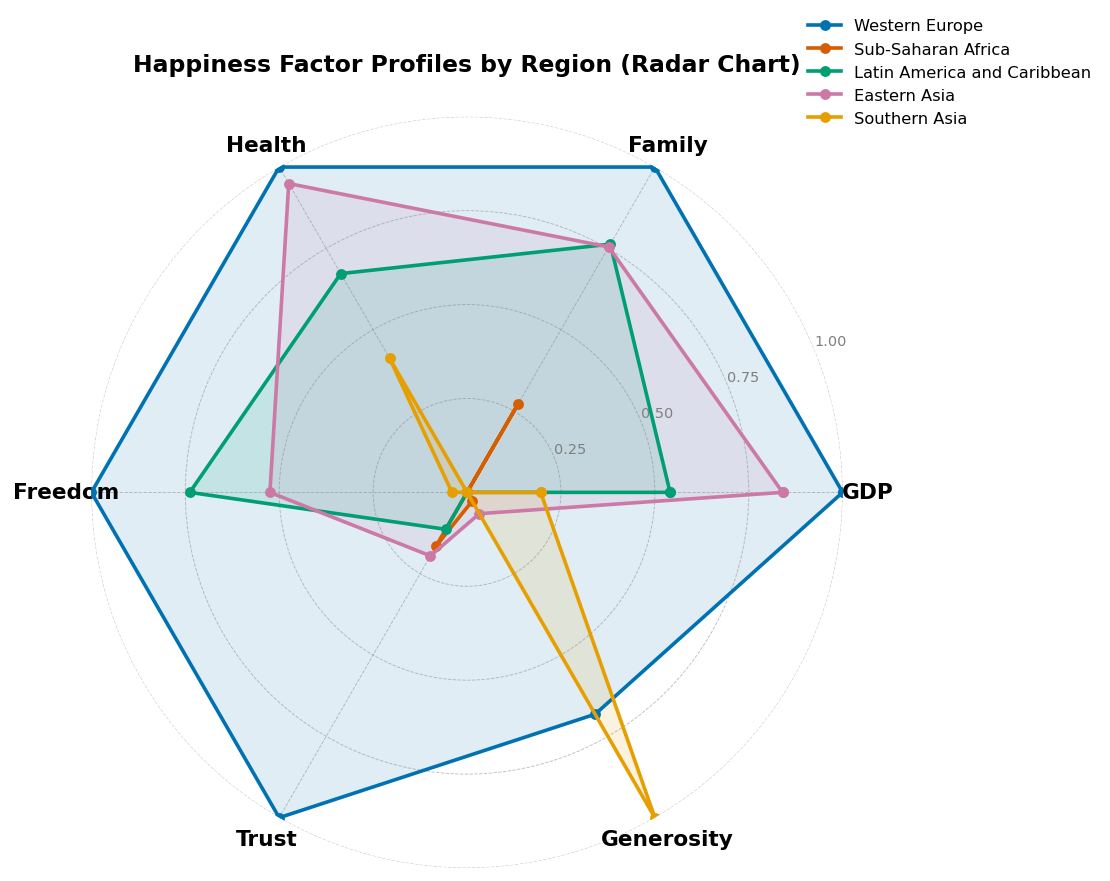

In [8]:
radar_regions = [
    'Western Europe', 'Sub-Saharan Africa',
    'Latin America and Caribbean', 'Eastern Asia', 'Southern Asia'
]
radar_factors = ['Economy (GDP per Capita)', 'Family',
                 'Health (Life Expectancy)', 'Freedom',
                 'Trust (Government Corruption)', 'Generosity']
factor_labels = ['GDP', 'Family', 'Health', 'Freedom', 'Trust', 'Generosity']

region_means = df[df['Region'].isin(radar_regions)]\
    .groupby('Region')[radar_factors].mean()

# Normalize 0–1
region_norm = (region_means - region_means.min()) / (region_means.max() - region_means.min())

N = len(radar_factors)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

radar_colors = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00']

for i, region in enumerate(radar_regions):
    values = region_norm.loc[region].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            color=radar_colors[i], label=region, markersize=5)
    ax.fill(angles, values, alpha=0.12, color=radar_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(factor_labels, fontsize=12, fontweight='bold')
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=8, color='gray')
ax.set_ylim(0, 1)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines['polar'].set_visible(False)

ax.set_title('Happiness Factor Profiles by Region (Radar Chart)',
             fontsize=13, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15),
          fontsize=9, framealpha=0)

plt.tight_layout()
plt.savefig('viz6_radar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 7 — Correlation Heatmap
### Type: Heatmap *(datavizproject.com)*

**Why this chart?**  
A heatmap of correlations shows all pairwise relationships simultaneously. Color intensity immediately identifies strong/weak correlations. The triangle mask removes redundant information.

**Design improvements:** Upper triangle masked, diverging colormap centered at 0, values annotated with 2 decimal places, dendrogram ordering groups related variables.

**Key insight:** GDP, Health, and Happiness Score are tightly correlated. Generosity shows the weakest relationship with the overall score.

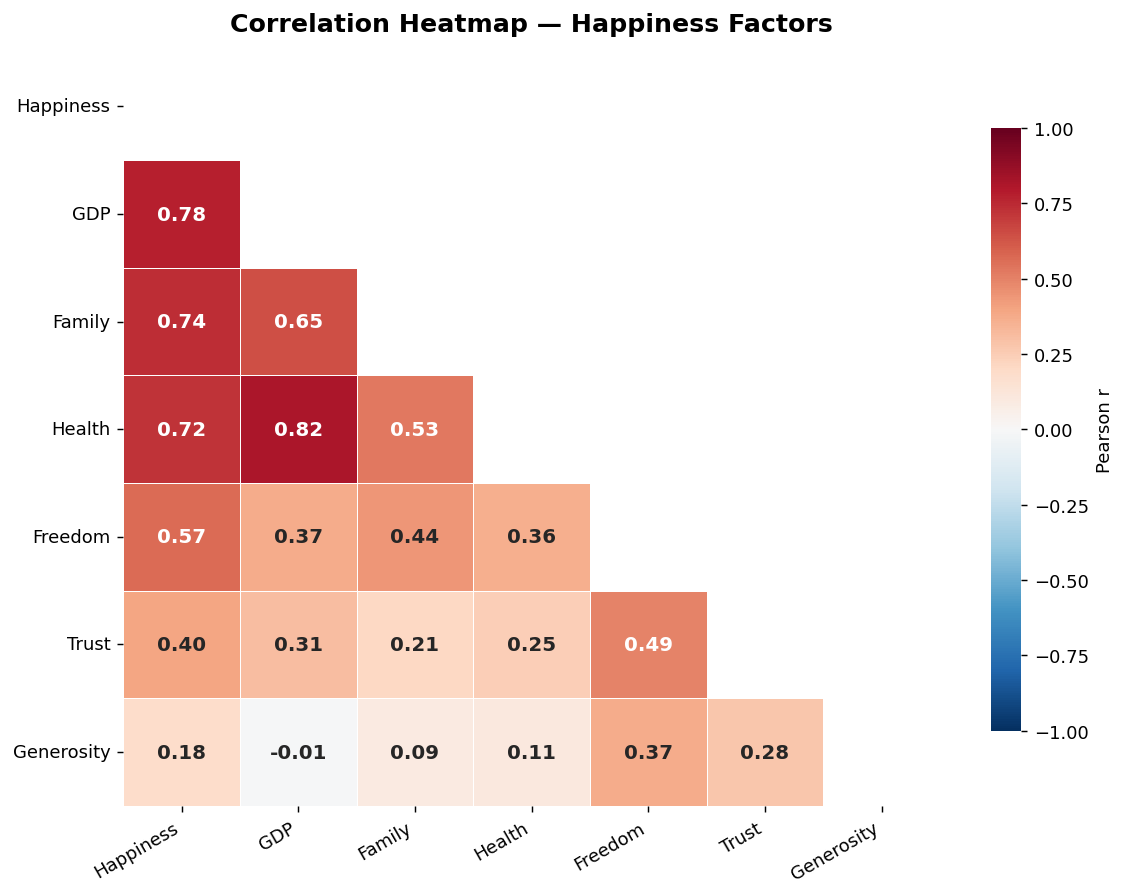

In [9]:
corr_cols = ['Happiness Score'] + factors
corr_labels = ['Happiness', 'GDP', 'Family', 'Health', 'Freedom', 'Trust', 'Generosity']
corr_matrix = df[corr_cols].corr()
corr_matrix.index   = corr_labels
corr_matrix.columns = corr_labels

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
    annot_kws={'size': 11, 'fontweight': 'bold'}
)

ax.set_title('Correlation Heatmap — Happiness Factors',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('viz7_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔀 ACT 4 — How Do Factors Interrelate?

## Visualization 8 — Parallel Coordinates: Top vs Bottom Countries
### Type: Parallel Coordinates Plot *(datavizproject.com)*

**Why this chart?**  
Parallel coordinates allow comparison of **many variables across many observations simultaneously**. Each line represents a country; its path across axes reveals its multi-factor profile. Convergence zones indicate shared patterns; crossings reveal trade-offs.

**Design improvements:** Top 20 in blue, bottom 20 in orange, middle countries in muted gray to highlight contrast. Colorblind-safe.

**Key insight:** Blue lines (top countries) consistently sit in the upper portion of every axis — they excel across ALL factors, not just one. Orange lines (bottom countries) are consistently low across all axes simultaneously.

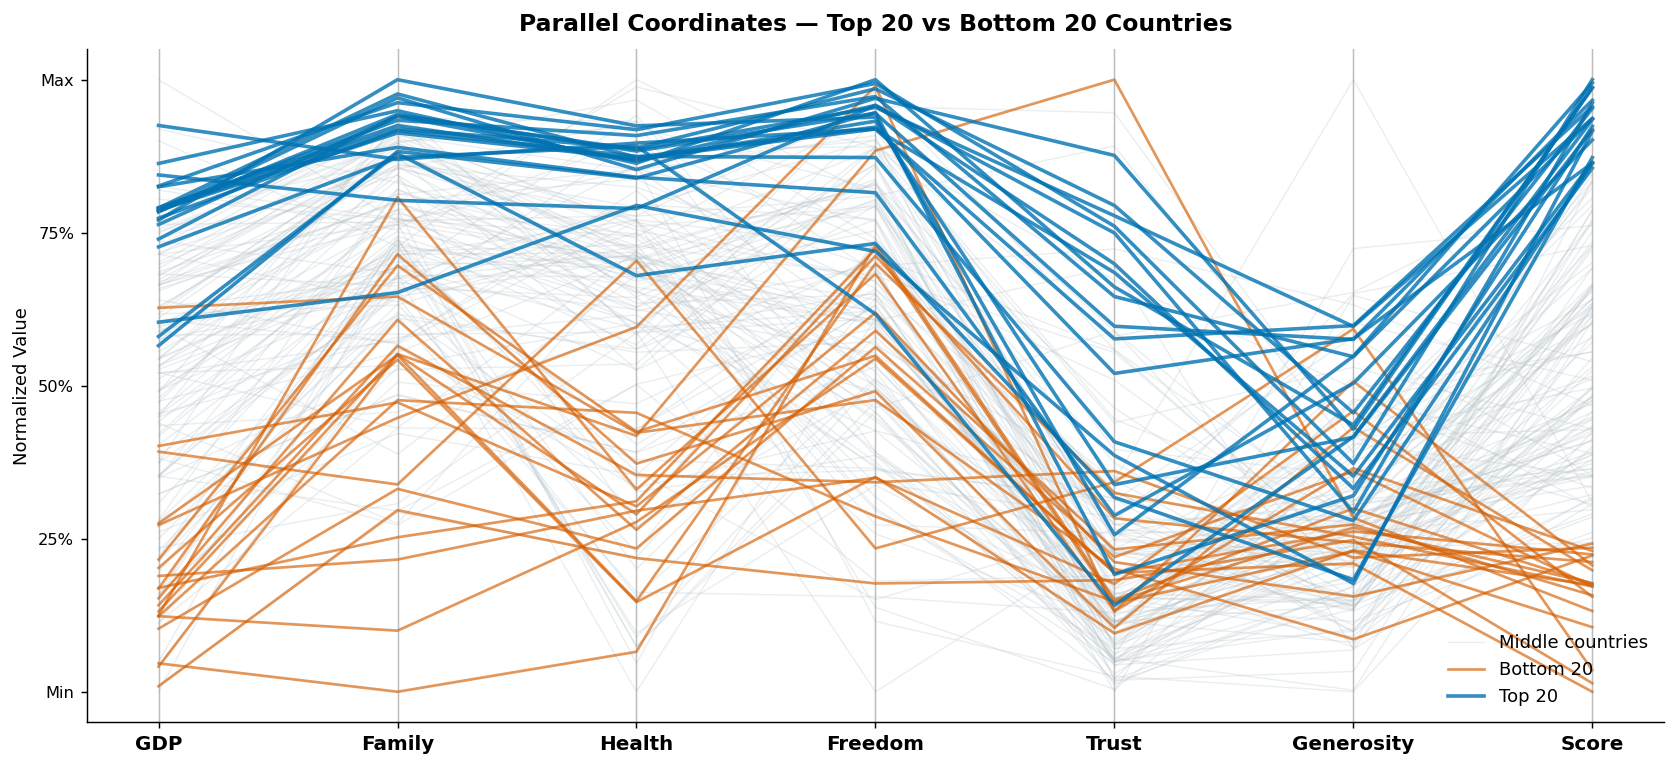

In [10]:
top20    = df.nlargest(20, 'Happiness Score')
bottom20 = df.nsmallest(20, 'Happiness Score')
middle   = df[~df['Country'].isin(top20['Country'].tolist() + bottom20['Country'].tolist())]

pc_cols = factors + ['Happiness Score']
pc_labels = ['GDP', 'Family', 'Health', 'Freedom', 'Trust', 'Generosity', 'Score']

# Normalize for parallel coords
df_pc = df[pc_cols].copy()
df_pc_norm = (df_pc - df_pc.min()) / (df_pc.max() - df_pc.min())

fig, ax = plt.subplots(figsize=(13, 6))

def draw_lines(idx_list, color, alpha, lw, label=None):
    for i, idx in enumerate(idx_list):
        row = df_pc_norm.loc[idx]
        ax.plot(range(len(pc_cols)), row.values,
                color=color, alpha=alpha, linewidth=lw,
                label=label if i == 0 else None)

draw_lines(middle.index,   '#B0BEC5', 0.25, 0.8,  'Middle countries')
draw_lines(bottom20.index, '#D55E00', 0.65, 1.5,  'Bottom 20')
draw_lines(top20.index,    '#0072B2', 0.80, 2.0,  'Top 20')

ax.set_xticks(range(len(pc_cols)))
ax.set_xticklabels(pc_labels, fontsize=11, fontweight='bold')
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['Min', '25%', '50%', '75%', 'Max'], fontsize=9)
ax.set_title('Parallel Coordinates — Top 20 vs Bottom 20 Countries',
             fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Normalized Value', fontsize=10)
ax.grid(True, axis='x', alpha=0.3, linewidth=0.8)

for x in range(len(pc_cols)):
    ax.axvline(x, color='gray', linewidth=0.8, alpha=0.4)

ax.legend(fontsize=10, frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig('viz8_parallel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 9 — Slope Chart: Regional Rank on GDP vs Freedom
### Type: Slope Chart *(datavizproject.com)*

**Why this chart?**  
A slope chart is designed to show **changes in ranking between two measures**. It reveals which regions rank consistently on both factors vs which regions are outliers — high on one but low on the other. The crossing of lines immediately signals reversals in ranking.

**Design improvements:** Colorblind-safe palette, labeled endpoints so no legend is needed, slope direction encoded by line angle.

**Key insight:** Eastern Asia ranks higher on GDP than on Freedom — suggesting economic development without political freedom. Latin America ranks higher on Freedom than on GDP.

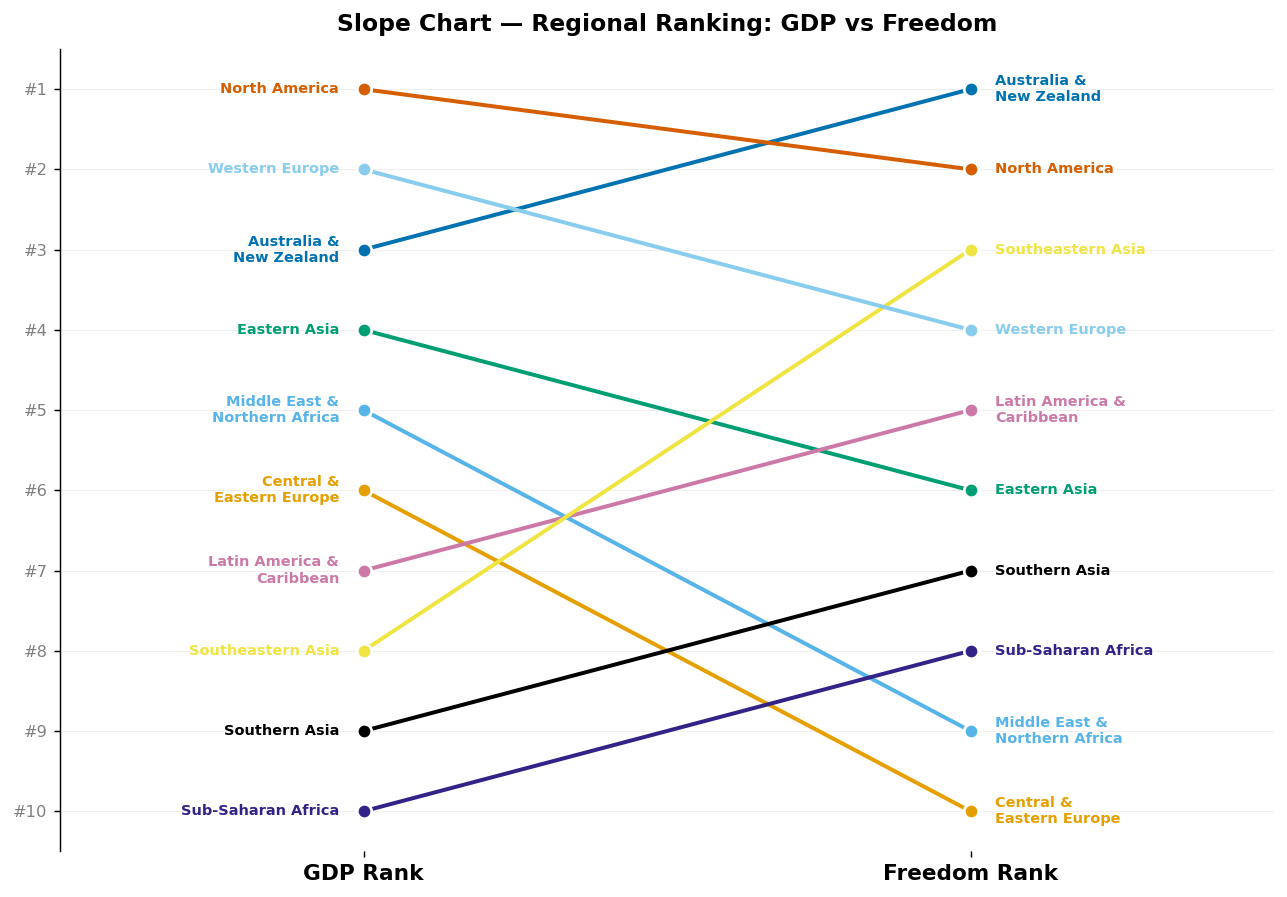

In [11]:
slope_data = df.groupby('Region')[['Economy (GDP per Capita)', 'Freedom']].mean().reset_index()
slope_data['GDP Rank']     = slope_data['Economy (GDP per Capita)'].rank(ascending=False).astype(int)
slope_data['Freedom Rank'] = slope_data['Freedom'].rank(ascending=False).astype(int)

fig, ax = plt.subplots(figsize=(10, 7))

slope_colors = CB_PALETTE[:len(slope_data)]

for i, (_, row) in enumerate(slope_data.iterrows()):
    color = slope_colors[i]
    ax.plot([0, 1], [row['GDP Rank'], row['Freedom Rank']],
            color=color, linewidth=2.2, marker='o', markersize=8,
            markerfacecolor=color, markeredgecolor='white', markeredgewidth=1.5)

    # Labels on left (GDP)
    ax.text(-0.04, row['GDP Rank'],
            f"{row['Region'].replace('and ', '&\n')}",
            ha='right', va='center', fontsize=8, color=color, fontweight='bold')

    # Labels on right (Freedom)
    ax.text(1.04, row['Freedom Rank'],
            f"{row['Region'].replace('and ', '&\n')}",
            ha='left', va='center', fontsize=8, color=color, fontweight='bold')

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(len(slope_data) + 0.5, 0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['GDP Rank', 'Freedom Rank'], fontsize=12, fontweight='bold')
ax.set_yticks(range(1, len(slope_data)+1))
ax.set_yticklabels([f'#{i}' for i in range(1, len(slope_data)+1)], fontsize=9, color='gray')
ax.set_title('Slope Chart — Regional Ranking: GDP vs Freedom',
             fontsize=13, fontweight='bold', pad=10)
ax.grid(True, axis='y', alpha=0.2, linewidth=0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.savefig('viz9_slope.png', dpi=150, bbox_inches='tight')
plt.show()

---
#  ACT 5 — Outliers & Patterns

## Visualization 10 — Dot Plot: Countries by Factor Strength
### Type: Dot Plot *(datavizproject.com)*

**Why this chart?**  
A dot plot is a clean alternative to a bar chart for showing ranked values. Unlike a bar chart, it draws attention to the **value position** rather than the bar area — making small differences more readable. Coloring by region reveals geographic clustering of factor strength.

**Design improvements:** Top 20 countries sorted by GDP, colored by region, region annotated via legend.

**Key insight:** Countries at the top of the GDP ranking are overwhelmingly from Western Europe, North America, and Australia.

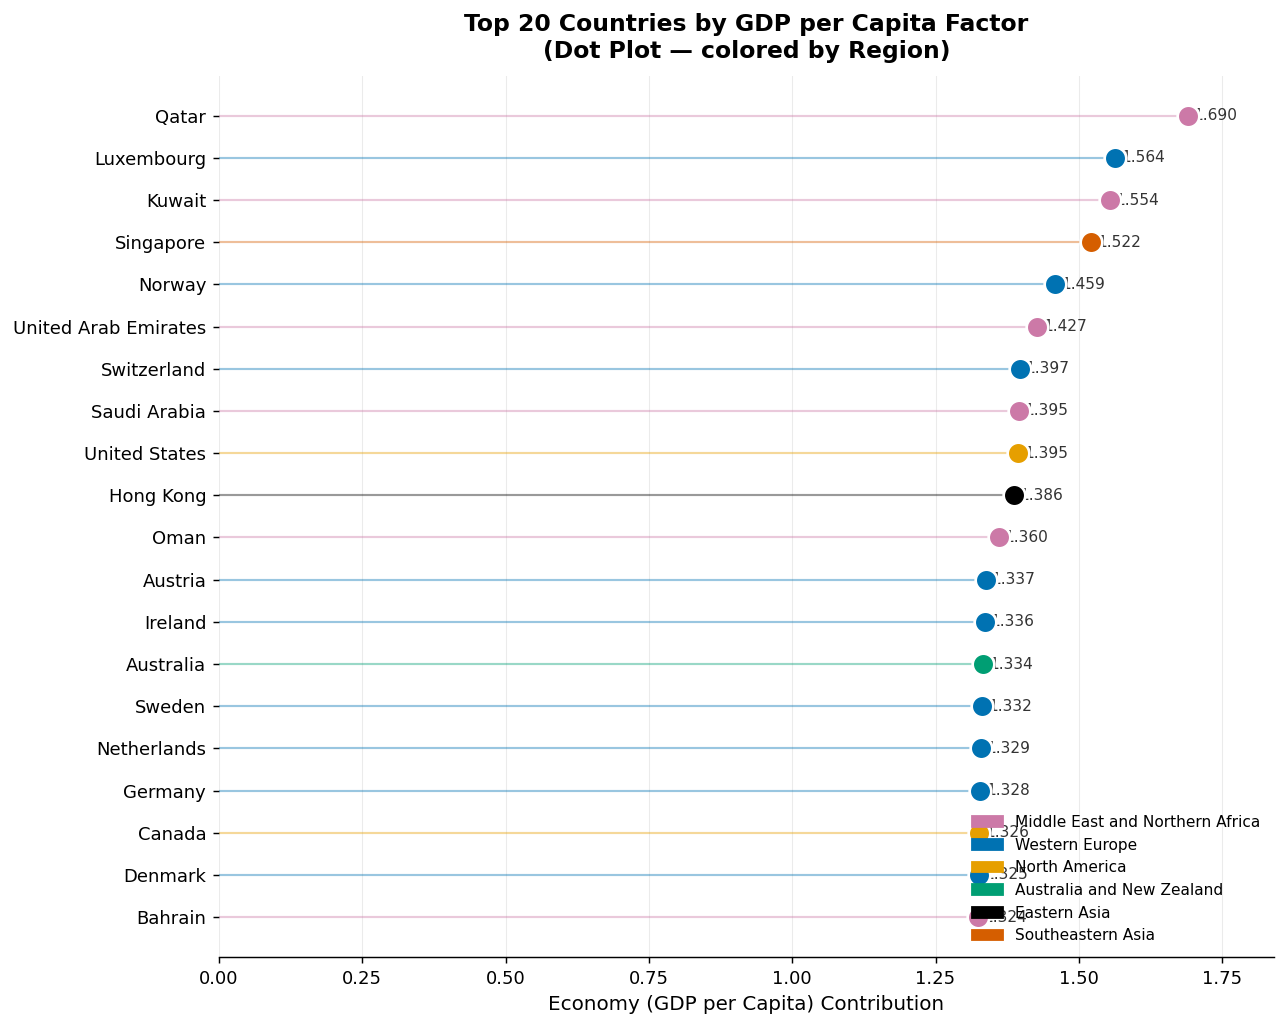

In [12]:
top20_gdp = df.nlargest(20, 'Economy (GDP per Capita)').sort_values('Economy (GDP per Capita)')

fig, ax = plt.subplots(figsize=(10, 8))

for _, row in top20_gdp.iterrows():
    color = region_color.get(row['Region'], '#999999')
    ax.plot(row['Economy (GDP per Capita)'], row['Country'],
            'o', color=color, markersize=12, markeredgecolor='white',
            markeredgewidth=1.5, zorder=5)
    ax.hlines(row['Country'], 0, row['Economy (GDP per Capita)'],
              color=color, linewidth=1.2, alpha=0.4)
    ax.text(row['Economy (GDP per Capita)'] + 0.01, row['Country'],
            f"{row['Economy (GDP per Capita)']:.3f}",
            va='center', fontsize=8.5, color='#333333')

ax.set_title('Top 20 Countries by GDP per Capita Factor\n(Dot Plot — colored by Region)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_xlabel('Economy (GDP per Capita) Contribution', fontsize=11)
ax.set_xlim(0, top20_gdp['Economy (GDP per Capita)'].max() + 0.15)
ax.grid(True, axis='x', alpha=0.25, linewidth=0.6)
ax.spines['left'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [
    mpatches.Patch(color=region_color[r], label=r)
    for r in top20_gdp['Region'].unique()
]
ax.legend(handles=legend_handles, fontsize=8.5, frameon=False,
          loc='lower right')

plt.tight_layout()
plt.savefig('viz10_dotplot.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 11 — Mosaic Plot: Region vs Happiness Tier
### Type: Mosaic Plot *(datavizproject.com)*

**Why this chart?**  
A mosaic plot encodes **two categorical variables** simultaneously — width represents the proportion of countries in each region, height represents the happiness tier breakdown within that region. This is uniquely suited for showing how categorical distributions vary across groups.

**Design improvements:** Colorblind-safe tier colors, width proportional to region size, labels inside tiles where space allows.

**Key insight:** Sub-Saharan Africa (wide column) is overwhelmingly in the low tier. Western Europe has no countries in the low tier.

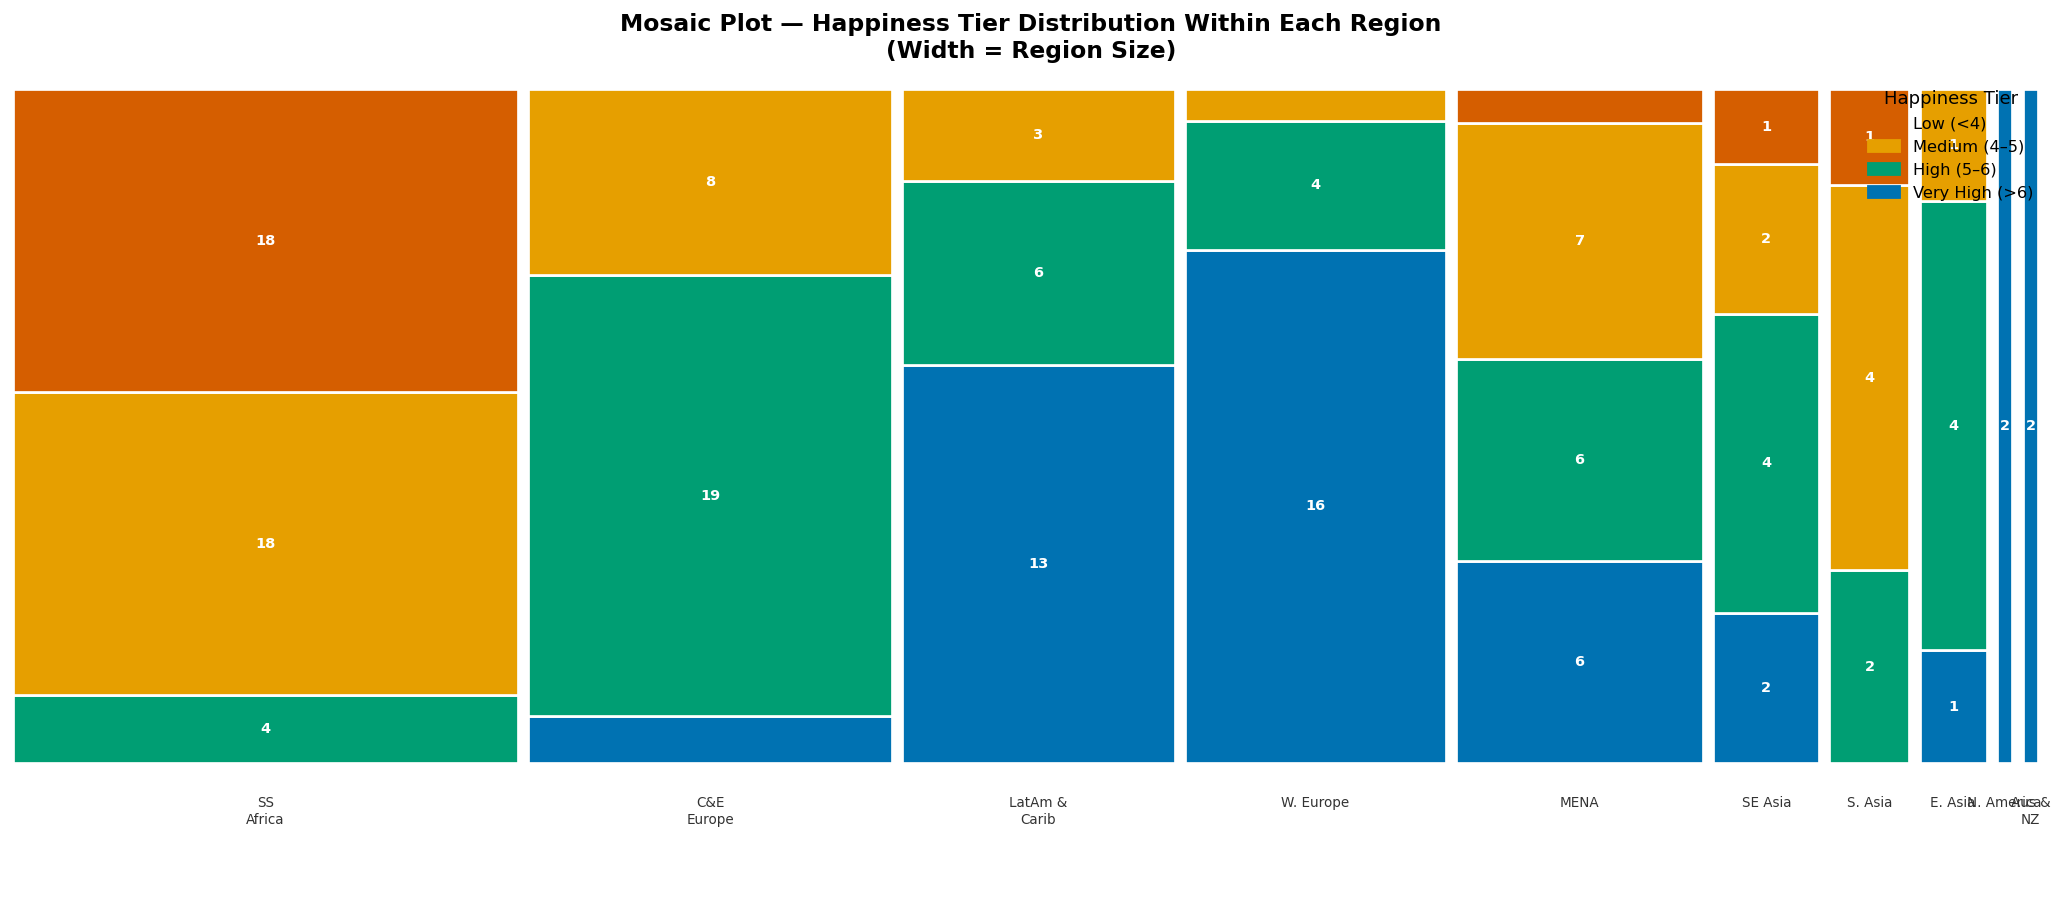

In [13]:
mosaic_data = pd.crosstab(df['Happiness Tier'], df['Region'])
mosaic_norm = mosaic_data.div(mosaic_data.sum(axis=0), axis=1)

tier_colors_m = {
    'Low (<4)':       '#D55E00',
    'Medium (4–5)':   '#E69F00',
    'High (5–6)':     '#009E73',
    'Very High (>6)': '#0072B2'
}

region_counts = df['Region'].value_counts()
region_widths = region_counts / region_counts.sum()
region_order_m = region_counts.index.tolist()

fig, ax = plt.subplots(figsize=(16, 7))

x_start = 0
gap = 0.005

for region in region_order_m:
    width = region_widths[region] - gap
    y_start = 0
    for tier in ['Very High (>6)', 'High (5–6)', 'Medium (4–5)', 'Low (<4)']:
        if tier in mosaic_norm.index and region in mosaic_norm.columns:
            height = mosaic_norm.loc[tier, region]
        else:
            height = 0
        if height > 0:
            rect = plt.Rectangle((x_start, y_start), width, height,
                                  facecolor=tier_colors_m[tier],
                                  edgecolor='white', linewidth=1.5)
            ax.add_patch(rect)
            if height > 0.08:
                count = mosaic_data.loc[tier, region] if tier in mosaic_data.index else 0
                ax.text(x_start + width/2, y_start + height/2,
                        f'{count}', ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')
        y_start += height

    # Region label
    short = region.replace('Sub-Saharan ','SS\n')\
                  .replace('Central and Eastern ','C&E\n')\
                  .replace('Latin America and Caribbean','LatAm &\nCarib')\
                  .replace('Western ','W. ')\
                  .replace('Middle East and Northern Africa','MENA')\
                  .replace('Southeastern ','SE ')\
                  .replace('Southern ','S. ')\
                  .replace('Eastern ','E. ')\
                  .replace('Australia and New Zealand','Aus &\nNZ')\
                  .replace('North America','N. America')
    ax.text(x_start + width/2, -0.05, short,
            ha='center', va='top', fontsize=7.5,
            rotation=0, color='#333333')
    x_start += region_widths[region]

ax.set_xlim(0, 1)
ax.set_ylim(-0.18, 1.02)
ax.set_title('Mosaic Plot — Happiness Tier Distribution Within Each Region\n(Width = Region Size)',
             fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Proportion', fontsize=11)
ax.axis('off')
ax.set_yticks([])

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in tier_colors_m.items()]
ax.legend(handles=legend_handles, loc='upper right',
          fontsize=9, framealpha=0, title='Happiness Tier')

plt.tight_layout()
plt.savefig('viz11_mosaic.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Visualization 12 — Interactive Parallel Coordinates (Plotly)
### Type: Parallel Coordinates Plot *(datavizproject.com)*

**Why this chart?**  
The interactive version allows filtering by dragging axis ranges — the viewer can select, for example, only high-GDP countries and immediately see their profiles across all other factors. This makes the chart a data exploration tool, not just a static display.

**Design improvements:** Continuous color scale by Happiness Score, interactive axis brushing, tooltips on hover.

**Key insight:** Countries with the highest scores (dark green lines) consistently occupy the upper range of every factor axis.

In [14]:
pc_plot_cols = ['Happiness Score'] + factors
pc_plot_labels = ['Score', 'GDP', 'Family', 'Health', 'Freedom', 'Trust', 'Generosity']

dimensions = [
    dict(range=[df[col].min(), df[col].max()],
         label=label, values=df[col])
    for col, label in zip(pc_plot_cols, pc_plot_labels)
]

fig = go.Figure(data=go.Parcoords(
    line=dict(
        color=df['Happiness Score'],
        colorscale='RdYlGn',
        showscale=True,
        colorbar=dict(title='Happiness Score')
    ),
    dimensions=dimensions
))

fig.update_layout(
    title='Interactive Parallel Coordinates — All Countries (drag axes to filter)',
    title_font_size=14,
    height=500,
    margin=dict(l=100, r=50, t=60, b=50)
)
fig.show()

---


## Top 5 Happiest Countries

In [15]:
top5 = df.nlargest(5, 'Happiness Score')[['Country','Region','Happiness Score'] + factors]
print("🏆 Top 5 Happiest Countries:")
print(top5.to_string(index=False))

🏆 Top 5 Happiest Countries:
    Country         Region  Happiness Score  Economy (GDP per Capita)  Family  Health (Life Expectancy)  Freedom  Trust (Government Corruption)  Generosity
Switzerland Western Europe            7.587                   1.39651 1.34951                   0.94143  0.66557                        0.41978     0.29678
    Iceland Western Europe            7.561                   1.30232 1.40223                   0.94784  0.62877                        0.14145     0.43630
    Denmark Western Europe            7.527                   1.32548 1.36058                   0.87464  0.64938                        0.48357     0.34139
     Norway Western Europe            7.522                   1.45900 1.33095                   0.88521  0.66973                        0.36503     0.34699
     Canada  North America            7.427                   1.32629 1.32261                   0.90563  0.63297                        0.32957     0.45811


## Top Contributing Factor Per Region

In [16]:
region_factors = df.groupby('Region')[factors].mean()
region_factors['Top Factor'] = region_factors.idxmax(axis=1)
region_factors['Top Value']  = region_factors[factors].max(axis=1).round(3)

print("\n📊 Top Contributing Factor per Region:")
print(region_factors[['Top Factor','Top Value']].to_string())


📊 Top Contributing Factor per Region:
                                               Top Factor  Top Value
Region                                                              
Australia and New Zealand                          Family      1.314
Central and Eastern Europe                         Family      1.053
Eastern Asia                     Economy (GDP per Capita)      1.152
Latin America and Caribbean                        Family      1.105
Middle East and Northern Africa  Economy (GDP per Capita)      1.067
North America                    Economy (GDP per Capita)      1.360
Southeastern Asia                                  Family      0.940
Southern Asia                                      Family      0.645
Sub-Saharan Africa                                 Family      0.809
Western Europe                   Economy (GDP per Capita)      1.299


## Outliers & Patterns

In [17]:
# Countries where actual score is very different from GDP-predicted score (outliers)
from scipy import stats

slope, intercept, r, p, se = stats.linregress(
    df['Economy (GDP per Capita)'], df['Happiness Score']
)
df['Predicted Score'] = slope * df['Economy (GDP per Capita)'] + intercept
df['Residual']        = df['Happiness Score'] - df['Predicted Score']

outliers_high = df.nlargest(5, 'Residual')[['Country','Region','Happiness Score','Residual']]
outliers_low  = df.nsmallest(5, 'Residual')[['Country','Region','Happiness Score','Residual']]

print("📈 Happier than GDP predicts (positive outliers):")
print(outliers_high.to_string(index=False))
print("\n📉 Less happy than GDP predicts (negative outliers):")
print(outliers_low.to_string(index=False))

📈 Happier than GDP predicts (positive outliers):
   Country                      Region  Happiness Score  Residual
Costa Rica Latin America and Caribbean            7.226  1.607053
    Mexico Latin America and Caribbean            7.187  1.424401
    Brazil Latin America and Caribbean            6.983  1.307577
Mozambique          Sub-Saharan Africa            4.971  1.287900
   Iceland              Western Europe            7.561  1.173349

📉 Less happy than GDP predicts (negative outliers):
 Country                          Region  Happiness Score  Residual
   Syria Middle East and Northern Africa            3.006 -1.963938
   Gabon              Sub-Saharan Africa            3.896 -1.954663
Bulgaria      Central and Eastern Europe            4.218 -1.526010
Botswana              Sub-Saharan Africa            4.332 -1.370729
   Egypt Middle East and Northern Africa            4.194 -1.260842


---

# 📝 Conclusions

| # | Visualization | Type | Key Insight |
|---|---|---|---|
| 1 | Top/Bottom 15 Countries | **Lollipop** | Western Europe dominates top; Sub-Saharan Africa dominates bottom |
| 2 | Score by Region | **Violin** | Western Europe: tight/high; Sub-Saharan Africa: wide spread |
| 3 | Happiness Tier Groups | **Waffle** | ~1/3 of countries in Medium tier; very few in Very High |
| 4 | Countries by Region | **Treemap** | Western Europe rectangles dominate the "happiness space" |
| 5 | World Map | **Choropleth** | Clear global north/south happiness divide |
| 6 | Factor Profiles | **Radar** | Western Europe balanced; Southern Asia high Family, low GDP |
| 7 | Factor Correlations | **Heatmap** | GDP + Health most correlated with happiness; Generosity weakest |
| 8 | Multi-factor Comparison | **Parallel Coordinates** | Top countries excel on ALL factors simultaneously |
| 9 | GDP vs Freedom Ranking | **Slope Chart** | Eastern Asia: high GDP, low Freedom — a key trade-off |
| 10 | Top GDP Countries | **Dot Plot** | Western Europe/North America monopolize the GDP top 20 |
| 11 | Region × Tier | **Mosaic** | Sub-Saharan Africa (largest region) almost entirely in Low tier |
| 12 | All Factors Interactive | **Parallel Coords (Plotly)** | High scorers consistently top on every axis |

### Overall Pattern
> **Economic prosperity (GDP) and health (life expectancy) are the strongest engines of happiness globally. However, outliers — countries happier than their GDP predicts (e.g., Latin America) and countries less happy (e.g., Middle East/Africa) — reveal that culture, social cohesion, and political freedom play critical roles beyond pure economics.**